Copyright 2025 Kevin Zambello

This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.

This program is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.

You should have received a copy of the GNU General Public License along with this program. If not, see https://www.gnu.org/licenses/.

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import sys

sys.path.insert(1, '..')

import numpy as np
import matplotlib.pyplot as plt

from qcd_tools import padefit

plt.rcParams["figure.figsize"] = (6, 3)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 100
plt.rcParams["legend.loc"] = 'upper right'
plt.rc('font', size=8)
plt.rc('axes', titlesize=12)
plt.rc('axes', labelsize=12)
plt.rc('xtick', labelsize=8)
plt.rc('ytick', labelsize=8)
plt.rc('legend', fontsize=8)
plt.rc('figure', titlesize=8)

Let's consider the function

$\chi_{true}(x) = i \frac{sin(-ix)}{\sqrt{ ((0.5+x)^2 + \pi^2)((0.5-x)^2 + \pi^2)(16-x^2)  }}$

with singularities at $x = \pm(i\pi + 0.5), ~ \pm(i\pi - 0.5), ~ \pm 4$.

In [2]:
def truechi(x):
    return 1.0j*np.sin(-1.0j*x)/np.sqrt(((0.5+x)**2 + np.pi**2)*((0.5-x)**2 + np.pi**2)*(16.0-x**2))

truesings = np.array([1.0j*np.pi+0.5,1.0j*np.pi-0.5,-1.0j*np.pi+0.5,-1.0j*np.pi-0.5,-4.0,4.0])

Let's plot the imaginary/real parts of $\chi_{true}(x)$ for $x$ either purely real ($x = x_R$) or purely imaginary ($x = i x_I$) and make a scatter plot of the singularities.

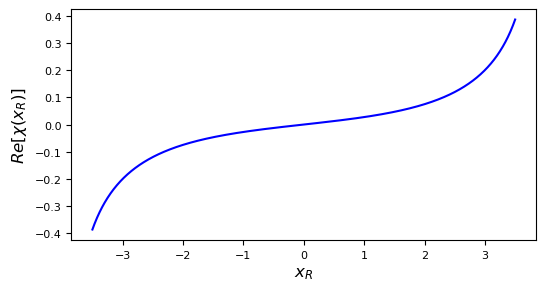

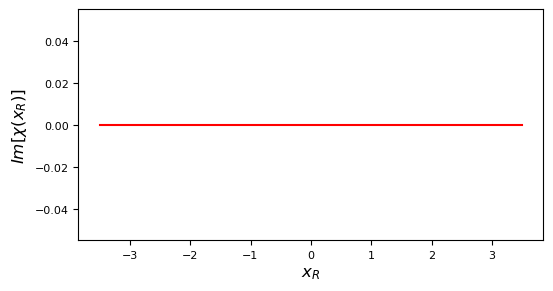

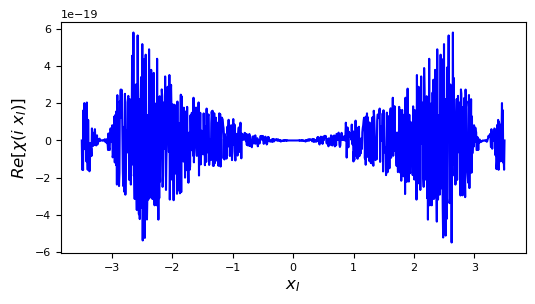

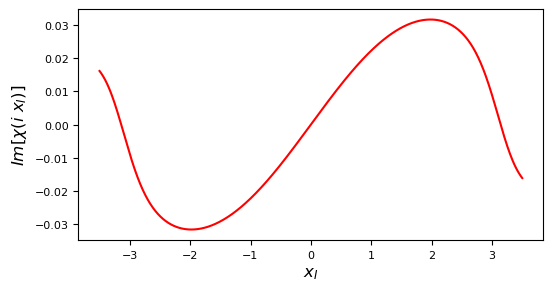

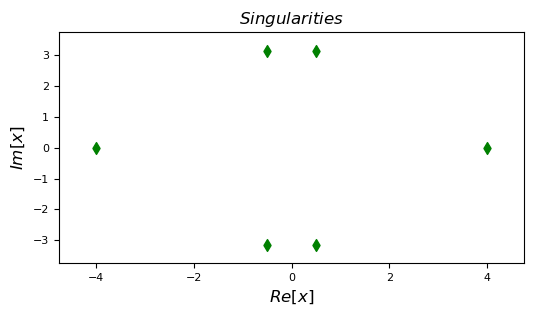

In [3]:
x = np.linspace(-3.5,3.5,1000)

plt.figure()
plt.plot(x,np.real(truechi(x)), 'b')
plt.ylabel('$Re[\chi(x_R)]$')
plt.xlabel('$x_R$')

plt.figure()
plt.plot(x,np.imag(truechi(x)), 'r')
plt.ylabel('$Im[\chi(x_R)]$')
plt.xlabel('$x_R$')

plt.figure()
plt.plot(x,np.real(truechi(x*1.0j)), 'b')
plt.xlabel('$x_I$')
plt.ylabel('$Re[\chi(i~x_I)]$')

plt.figure()
plt.plot(x,np.imag(truechi(x*1.0j)), 'r')
plt.xlabel('$x_I$')
plt.ylabel('$Im[\chi(i~x_I)]$')

plt.figure()
plt.scatter(np.real(truesings),np.imag(truesings), marker='d', color='g')
plt.xlabel('$Re[x]$')
plt.ylabel('$Im[x]$')
plt.xlim([-4.75,4.75]);
plt.ylim([-3.75,3.75]);
plt.title("$Singularities$")

plt.show()

Now let's suppose that we want to study the complex singularities of $\chi_{true}(x)$, but we can only evalute:

$\bullet$ the imaginary part of the function at purely imaginary $x= i x_I$, that is $\chi_1 (x_I) \equiv Im(\chi_{true}(i x_I))$

$\bullet$ its derivatives $\chi_n (x_I) \equiv \frac{d^n}{dx_I^n} \chi_1 (x_I)$

Moreover the evaluation is numerical, our knowledge about $\chi_{true}(x)$ consists in noisy estimates of $\chi_1$ at a finite number of points $\{x^{n}_{I,sim}\}_{n=1}^{N_{points}}$.

In [4]:
def chi1(xi):
    return np.imag(truechi(1.0j * xi))

# quick and dirty derivatives using finite differences
def chi2(xi):
    h = 1e-5
    return (chi1(xi+h/2.0)-chi1(xi-h/2.0))/h

def chi3(xi):
    h = 1e-5
    return (chi1(xi+h)+chi1(xi-h)-2.0*chi1(xi))/(h*h)

def chi4(xi):
    h = 1e-5
    return (chi1(xi+2*h)-2.0*chi1(xi+h)+2.0*chi1(xi-h)-chi1(xi-2*h))/(2*h*h*h)

Let's simulate a numerical experiment where we measure $\chi_1$ at $20$ equispaced points between $-3.50$ and $3.50$,
with a noise $\epsilon = 0.01$. We also measure the first, second and third derivatives with $\epsilon = 0.05, 0.10$ and $0.15$.

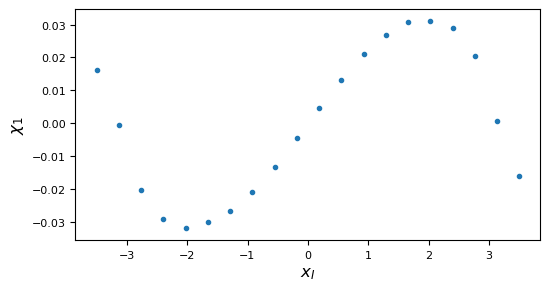

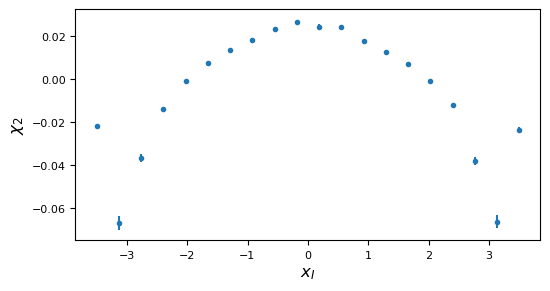

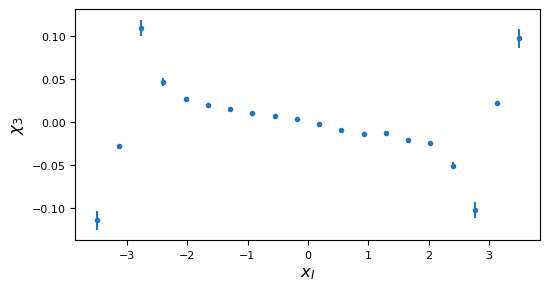

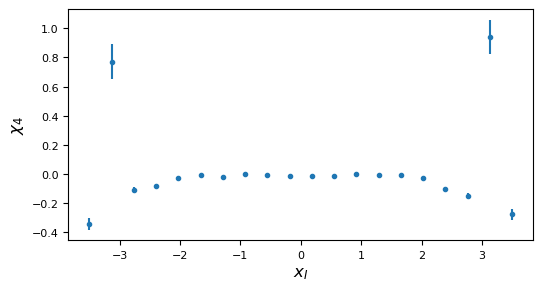

In [5]:
xi_sim = np.linspace(-3.50,3.50,20)

eps1 = 1.0e-2
eps2 = 5.0e-2
eps3 = 1.0e-1
eps4 = 1.5e-1

chis = [chi1(xi_sim),chi2(xi_sim), chi3(xi_sim), chi4(xi_sim)]
dchis = [eps1*np.abs(chis[0]), eps2*np.abs(chis[1]), eps3*np.abs(chis[2]), eps4*np.abs(chis[3])]
chis = [chis[0]+np.random.randn(len(xi_sim))*dchis[0],
        chis[1]+np.random.randn(len(xi_sim))*dchis[1],
        chis[2]+np.random.randn(len(xi_sim))*dchis[2],
        chis[3]+np.random.randn(len(xi_sim))*dchis[3]]

plt.figure()
plt.errorbar(xi_sim, chis[0], dchis[0], marker='.', linestyle='')
plt.xlabel("$x_I$")
plt.ylabel("$\chi_1$")

plt.figure()
plt.errorbar(xi_sim, chis[1], dchis[1], marker='.', linestyle='')
plt.xlabel("$x_I$")
plt.ylabel("$\chi_2$")

plt.figure()
plt.errorbar(xi_sim, chis[2], dchis[2], marker='.', linestyle='')
plt.xlabel("$x_I$")
plt.ylabel("$\chi_3$")

plt.figure()
plt.errorbar(xi_sim, chis[3], dchis[3], marker='.', linestyle='')
plt.xlabel("$x_I$")
plt.ylabel("$\chi_4$")

plt.show()

Let's fit our data for $\chi_1$ to $R_9^9$ multi-point Pad\'e approximants. We choose $R_9^9$ because this is the lowest degree for which we get good fits having $\frac{\chi_2}{ndof} \lesssim 1.5$ ($1.5$ times the number of derivatives included in the fit) in a significant number cases. If we plot the zeros and poles of the approximants we see observe:

$\bullet$ cases of zero/pole cancellation

$\bullet$ poles clustering around the singularities close to the imaginary axis

$\bullet$ other poles floating around in the complex plane

>>> Proc 597068 <<<
Number of points = 20
Number of constraints = 21 (for 20 points)
Number of coefficients = 20
Number of degrees of freedom = 1

Rational function: (C_0*x**9 + C_1*x**8 + C_2*x**7 + C_3*x**6 + C_4*x**5 + C_5*x**4 + C_6*x**3 + C_7*x**2 + C_8*x + C_9)/(C_10*x**9 + C_11*x**8 + C_12*x**7 + C_13*x**6 + C_14*x**5 + C_15*x**4 + C_16*x**3 + C_17*x**2 + C_18*x + C_19)
--------------------------------------------------

>>> Proc 597068 [sample #1 of 100] <<<
Rational function: (1.77324707569995e-5*x**9 + 7.06366755041094e-5*x**8 - 0.000467492102414131*x**7 - 0.00195660386054457*x**6 + 0.0043330408270533*x**5 + 0.0161287174500225*x**4 - 0.0167834139460392*x**3 - 0.0365168205064081*x**2 + 0.0247180735109257*x + 1.38305976339501e-5)/(0.000237496849849304*x**9 - 3.08656529479351e-5*x**8 - 0.00408307088023142*x**7 - 0.00675863166483755*x**6 - 0.0112403604992869*x**5 + 0.113997052501181*x**4 + 0.481116742361335*x**3 - 0.570246198298386*x**2 - 1.46676834477212*x + 0.99706227665842)
--

>>> Proc 597068 [sample #14 of 100] <<<
Rational function: (2.2096635618607e-5*x**9 - 1.30658771088729e-5*x**8 - 0.000588331762518913*x**7 + 0.000285853638023201*x**6 + 0.00533804020813169*x**5 - 0.00179130584773253*x**4 - 0.0191122045915668*x**3 + 0.00240339003724438*x**2 + 0.0245677122731359*x - 4.09312283108046e-5)/(1.96181081024616e-5*x**9 + 8.00357242794106e-5*x**8 - 0.000488331648531648*x**7 - 0.0105595982951616*x**6 + 0.00909963456771858*x**5 + 0.155624444713198*x**4 - 0.0704857705736814*x**3 - 0.684147936621729*x**2 + 0.0980966970650409*x + 0.996903884161321)
--------------------------------------------------

>>> Proc 597068 [sample #15 of 100] <<<
Rational function: (-0.000107666201289396*x**9 + 1.26788331040705e-5*x**8 + 0.00237393806585171*x**7 - 0.000299257501664915*x**6 - 0.0133120461248706*x**5 - 0.000377310839051503*x**4 + 0.00112333225469972*x**3 + 0.0206770574315892*x**2 + 0.0252694576883465*x + 5.77391243008356e-5)/(0.000111759772808092*x**9 - 0.00191043962846708*x**

>>> Proc 597068 [sample #28 of 100] <<<
Rational function: (5.50717077685744e-5*x**9 - 1.57234654439429e-6*x**8 - 0.00140753460173673*x**7 - 5.39564224126927e-5*x**6 + 0.0117432481075546*x**5 + 0.00141437339321027*x**4 - 0.03423531688734*x**3 - 0.00719170993061979*x**2 + 0.0245179766928915*x + 3.77156761042461e-5)/(5.41806132425272e-6*x**9 + 0.000276576607172226*x**8 - 6.43573337461223e-5*x**7 - 0.0276911419790225*x**6 + 0.00021495997659294*x**5 + 0.369426930423759*x**4 + 0.0342905416757646*x**3 - 1.31167908385698*x**2 - 0.294827622058163*x + 0.999494651132601)
--------------------------------------------------

>>> Proc 597068 [sample #29 of 100] <<<
Rational function: (0.000155893288522565*x**9 - 0.000107504881318543*x**8 - 0.00362190033536975*x**7 + 0.00236793824033457*x**6 + 0.0243528725484619*x**5 - 0.0129648748493604*x**4 - 0.040083847380409*x**3 + 0.000664112455368235*x**2 + 0.0258744877874619*x + 0.000132613552690633)/(7.39325863502677e-5*x**9 + 0.0016609958449184*x**8 - 0.0036

>>> Proc 597068 [sample #42 of 100] <<<
Rational function: (-6.35005201309379e-5*x**9 + 0.00017699329460624*x**8 + 0.00152777800215932*x**7 - 0.0047390735344073*x**6 - 0.0102516812293287*x**5 + 0.0362455877002466*x**4 + 0.0108899942210967*x**3 - 0.0662875406740442*x**2 + 0.024991081787482*x + 1.08314096905941e-6)/(0.000491654511648845*x**9 - 0.00102833275559082*x**8 - 0.00713392570103777*x**7 + 0.0426071485513668*x**6 - 0.0544893429610075*x**5 - 0.420766927108003*x**4 + 1.19704026844395*x**3 + 0.602705183011339*x**2 - 2.69475942589053*x + 1.00115051689644)
--------------------------------------------------

>>> Proc 597068 [sample #43 of 100] <<<
Rational function: (-2.3106869772678e-5*x**9 + 9.80107019603099e-5*x**8 + 0.000502447774116773*x**7 - 0.0025587943008645*x**6 - 0.0026404888504418*x**5 + 0.0198791338184604*x**4 - 0.0031975798158561*x**3 - 0.0411953093804668*x**2 + 0.0250374990230015*x - 3.42004819713074e-5)/(0.000240989186175568*x**9 - 0.000301725266143825*x**8 - 0.0040233104

>>> Proc 597068 [sample #56 of 100] <<<
Rational function: (-4.2010762411083e-5*x**9 - 6.80321382896228e-5*x**8 + 0.000933776493820139*x**7 + 0.00169019740061074*x**6 - 0.00554243499213342*x**5 - 0.0131082870107331*x**4 + 0.00164459041946341*x**3 + 0.0301619078728903*x**2 + 0.024687887510831*x - 4.42186508292842e-5)/(-6.97102701189019e-5*x**9 - 0.000499174541898912*x**8 + 0.00119099416084453*x**7 + 0.0259291381576793*x**6 + 0.024124445373185*x**5 - 0.242107878495514*x**4 - 0.413696807827105*x**3 + 0.201994265387744*x**2 + 1.23274039703276*x + 0.998489078667252)
--------------------------------------------------

>>> Proc 597068 [sample #57 of 100] <<<
Rational function: (4.56018508165225e-5*x**9 + 4.16068471514185e-5*x**8 - 0.00117016674824033*x**7 - 0.00130934949225533*x**6 + 0.00972327831035721*x**5 + 0.0120262459781256*x**4 - 0.0283361749121963*x**3 - 0.0311494868775463*x**2 + 0.0247380903211027*x - 5.40572297309102e-5)/(0.000237992129656144*x**9 + 0.000329510806720873*x**8 - 0.0042

>>> Proc 597068 [sample #70 of 100] <<<
Rational function: (0.000252360624463242*x**9 + 0.000304789739990055*x**8 - 0.00600236826464099*x**7 - 0.00727661234152689*x**6 + 0.0441778650813944*x**5 + 0.0530360581735898*x**4 - 0.0965512795707202*x**3 - 0.107738975063821*x**2 + 0.0249779312374561*x - 0.00013054099249086)/(0.000102828068323652*x**9 + 0.00123513392254817*x**8 - 0.000357946385107103*x**7 - 0.125353440896671*x**6 - 0.143959263247893*x**5 + 1.4862449817683*x**4 + 1.80794364115502*x**3 - 3.8555602977161*x**2 - 4.45042329963391*x + 0.999489579757827)
--------------------------------------------------

>>> Proc 597068 [sample #71 of 100] <<<
Rational function: (5.37197355415071e-5*x**9 + 1.61097947794862e-5*x**8 - 0.00135245457163778*x**7 - 0.000381050296289293*x**6 + 0.0110265510469671*x**5 + 0.00269193094880227*x**4 - 0.0311914250364317*x**3 - 0.00494761937226628*x**2 + 0.0241549312860983*x + 4.04450762496592e-5)/(1.01628485239581e-5*x**9 + 0.00030626049449639*x**8 - 0.00012432991

>>> Proc 597068 [sample #84 of 100] <<<
Rational function: (4.64700849391518e-5*x**9 - 1.95724980262875e-5*x**8 - 0.0011995994466843*x**7 + 0.000551078589312588*x**6 + 0.0103609654688624*x**5 - 0.00407025732005421*x**4 - 0.0326066287810631*x**3 + 0.00531355130138941*x**2 + 0.0248123355473368*x - 8.99154716031836e-6)/(-0.000133573576572996*x**9 + 2.6712958979277e-5*x**8 + 0.00231881230589091*x**7 - 0.0200159458623025*x**6 - 0.00297276871328419*x**5 + 0.302941727774128*x**4 - 0.121184678896928*x**3 - 1.22021507425688*x**2 + 0.201593278831646*x + 1.00126800734881)
--------------------------------------------------

>>> Proc 597068 [sample #85 of 100] <<<
Rational function: (8.15708059149444e-5*x**9 + 3.23788531943934e-5*x**8 - 0.00203780697624677*x**7 - 0.000990506015141073*x**6 + 0.0164513367866691*x**5 + 0.00948935899383971*x**4 - 0.0448259659778786*x**3 - 0.0283058656187713*x**2 + 0.0248559422675031*x + 1.62911628899589e-5)/(0.000102629178255193*x**9 + 0.000269153266776489*x**8 - 0.001

>>> Proc 597068 [sample #98 of 100] <<<
Rational function: (7.88429813769608e-5*x**9 + 0.000192110351284144*x**8 - 0.00185691208127973*x**7 - 0.00457532825531165*x**6 + 0.0136826098386187*x**5 + 0.032692342934794*x**4 - 0.032515431455502*x**3 - 0.0617386740016833*x**2 + 0.0249733941278702*x + 2.91463805146043e-5)/(0.00013766072866034*x**9 + 0.000229327861107343*x**8 - 0.0019399535234319*x**7 - 0.0364868724804592*x**6 - 0.0767250367993401*x**5 + 0.443709461027249*x**4 + 1.08278673294462*x**3 - 1.21518349312354*x**2 - 2.49904996696775*x + 1.00219166417785)
--------------------------------------------------

>>> Proc 597068 [sample #99 of 100] <<<
Rational function: (3.38692684920565e-5*x**9 + 1.9756436531986e-5*x**8 - 0.000881359926677613*x**7 - 0.000529072822490832*x**6 + 0.00773168929713127*x**5 + 0.00472853984657688*x**4 - 0.02550706428771*x**3 - 0.0141330075024189*x**2 + 0.0244980544013283*x + 2.29017779761516e-5)/(3.22103171411238e-6*x**9 + 4.49557079219079e-5*x**8 - 9.3212887575313

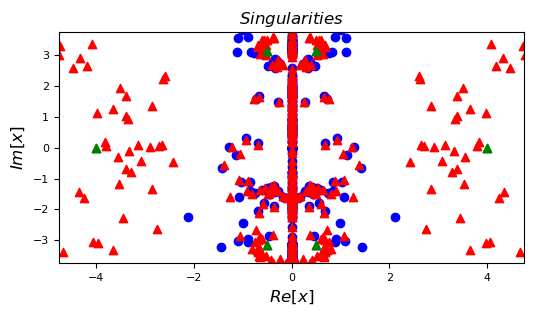

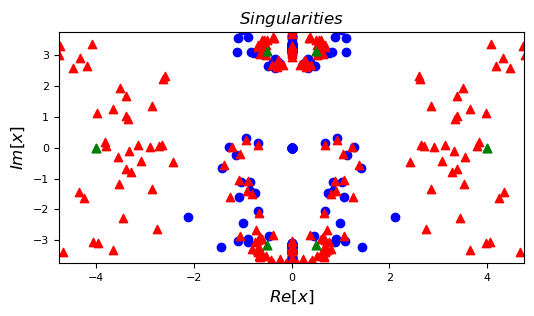

In [6]:
constraints = 1 * np.ones(len(xi_sim), dtype=int)

ncoeffs_num = 10
ncoeffs_den = 10
nsamples = 100
chi_threshold = 1.5
tol_cancellation = 5.0e-2

[sol_f_lst, roots_num_arr_lst, roots_den_arr_lst, chi_square_lst, residues_arr_lst] = padefit.fit(
    xi_sim, chis, dchis, constraints, ncoeffs_num, ncoeffs_den, nsamples=nsamples)

print(f"\nPercentage of good fits: {np.sum(np.array(chi_square_lst) < chi_threshold) / np.array(chi_square_lst).size}\n")

#xx = np.linspace(np.min(xi_sim),np.max(xi_sim),100)
#plt.figure()
#for n in range(nsamples):
#    if chi_square_lst[n] < chi_threshold:
#        plt.plot(xx, sol_f_lst[n](xx), 'b-')
#plt.plot(xx, chi1(xx), 'g-')
#plt.ylim([-0.035,0.035])

plt.figure()
[a, b, c] = padefit.squeeze_roots_lst(roots_num_arr_lst, roots_den_arr_lst, chi_square_lst, residues_arr_lst, chi_threshold=chi_threshold, tol_cancellation=None)
plt.scatter(np.real(a),np.imag(a), marker='o', color='b')
plt.scatter(np.real(b),np.imag(b), marker='^', color='r')
plt.scatter(np.real(truesings),np.imag(truesings), marker='^', color='g')
plt.scatter(np.real(truesings),np.imag(truesings), marker='^', color='g')
plt.xlabel('$Re[x]$')
plt.ylabel('$Im[x]$')
plt.xlim([-4.75,4.75])
plt.ylim([-3.75,3.75])
plt.title("$Singularities$")

plt.figure()
[a, b, c] = padefit.squeeze_roots_lst(roots_num_arr_lst, roots_den_arr_lst, chi_square_lst, residues_arr_lst, chi_threshold=chi_threshold, tol_cancellation=tol_cancellation)
plt.scatter(np.real(a),np.imag(a), marker='o', color='b')
plt.scatter(np.real(b),np.imag(b), marker='^', color='r')
plt.scatter(np.real(truesings),np.imag(truesings), marker='^', color='g')
plt.scatter(np.real(truesings),np.imag(truesings), marker='^', color='g')
plt.xlabel('$Re[x]$')
plt.ylabel('$Im[x]$')
plt.xlim([-4.75,4.75])
plt.ylim([-3.75,3.75])
plt.title("$Singularities$")

plt.show()

Now let's use also $\chi_2$ and $\chi_3$. We fit the data to $R_9^9$ multi-point Pad\'e approximants. e choose $R_9^9$ because this is the lowest degree for which we get good fits having $\frac{\chi_2}{ndof} \lesssim 4.5$ ($1.5$ times the number of derivatives included in the fit) in a significant number cases. If we plot the zeros and poles of the approximants we see many cases of zero/pole cancellations. The poles that were floating around in the complex plane seems to be moving towards the two singularities on the real axis.

>>> Proc 597449 <<<
Number of points = 20
Number of constraints = 61 (for 20 points)
Number of coefficients = 20
Number of degrees of freedom = 41

Rational function: (C_0*x**9 + C_1*x**8 + C_2*x**7 + C_3*x**6 + C_4*x**5 + C_5*x**4 + C_6*x**3 + C_7*x**2 + C_8*x + C_9)/(C_10*x**9 + C_11*x**8 + C_12*x**7 + C_13*x**6 + C_14*x**5 + C_15*x**4 + C_16*x**3 + C_17*x**2 + C_18*x + C_19)
--------------------------------------------------
>>> Proc 597450 <<<
Number of points = 20
Number of constraints = 61 (for 20 points)
Number of coefficients = 20
Number of degrees of freedom = 41

Rational function: (C_0*x**9 + C_1*x**8 + C_2*x**7 + C_3*x**6 + C_4*x**5 + C_5*x**4 + C_6*x**3 + C_7*x**2 + C_8*x + C_9)/(C_10*x**9 + C_11*x**8 + C_12*x**7 + C_13*x**6 + C_14*x**5 + C_15*x**4 + C_16*x**3 + C_17*x**2 + C_18*x + C_19)
--------------------------------------------------


>>> Proc 597449 [sample #1 of 50] <<<
Rational function: (1.75980586786403e-6*x**9 + 1.76010099832194e-6*x**8 - 7.2582768203634e-5*x**


>>> Proc 597449 [sample #7 of 50] <<<
Rational function: (1.14458749559504e-6*x**9 + 1.96608118526274e-6*x**8 - 5.24506580610038e-5*x**7 - 4.32630219417178e-5*x**6 + 0.000972946174576135*x**5 + 0.000420781819523163*x**4 - 0.00819919979070942*x**3 - 0.00182927218596333*x**2 + 0.025712902727727*x + 2.28181503014265e-6)/(-3.01211363140375e-5*x**9 - 6.73658424739638e-5*x**8 + 0.000681727293692931*x**7 + 0.00103150011618248*x**6 - 0.00622381171244712*x**5 + 0.0069445545847784*x**4 + 0.0293675677921652*x**3 - 0.211435832854953*x**2 - 0.0979300406281172*x + 1.0294888317992)
--------------------------------------------------

>>> Proc 597450 [sample #7 of 50] <<<
Rational function: (2.35701574752009e-6*x**9 + 2.3282169093023e-6*x**8 - 9.27350488344034e-5*x**7 - 6.65610806898297e-5*x**6 + 0.00144017854508693*x**5 + 0.000704147314133433*x**4 - 0.00999263638587879*x**3 - 0.00272153683564301*x**2 + 0.0251259176593407*x + 0.000168335170861282)/(-9.02990546403328e-6*x**9 - 7.93350926079426e-5*x**8 


>>> Proc 597449 [sample #15 of 50] <<<
Rational function: (2.25149526059292e-6*x**9 + 1.55640566063191e-6*x**8 - 8.97860632639958e-5*x**7 - 2.97917848705392e-5*x**6 + 0.00142018296900247*x**5 + 0.000221614386773948*x**4 - 0.00995645498695451*x**3 - 0.000777301270948998*x**2 + 0.0248829181810261*x - 4.38496352674201e-5)/(-2.27170380782297e-5*x**9 - 8.64181297927976e-5*x**8 + 0.000520173731685688*x**7 + 0.000674641354663353*x**6 - 0.00469359365393338*x**5 + 0.0194823041349129*x**4 + 0.0193202445964108*x**3 - 0.292646556119686*x**2 - 0.0464095032672383*x + 1.00283712513943)
--------------------------------------------------

>>> Proc 597450 [sample #13 of 50] <<<
Rational function: (1.94342228330962e-6*x**9 + 2.45418849946868e-6*x**8 - 8.14941911080352e-5*x**7 - 7.66803310544697e-5*x**6 + 0.0013358916160685*x**5 + 0.000939783517541061*x**4 - 0.00957293739489732*x**3 - 0.00416823306803669*x**2 + 0.024259233731222*x + 2.42417613738735e-5)/(-9.10970269685107e-6*x**9 - 6.2727756432261e-5*x**


>>> Proc 597450 [sample #19 of 50] <<<
Rational function: (1.50684537595065e-6*x**9 + 1.14897781729454e-6*x**8 - 6.41506860109906e-5*x**7 - 3.47899661942204e-5*x**6 + 0.00108460840360178*x**5 + 0.000363538823062246*x**4 - 0.0084094455052948*x**3 - 0.00132000635580397*x**2 + 0.0247229699104527*x + 0.000159764136133005)/(-2.59901425119117e-6*x**9 - 4.98311596043042e-5*x**8 + 6.67393060439212e-5*x**7 + 0.00047935279588444*x**6 - 0.00112121431153517*x**5 + 0.0130181484546945*x**4 + 0.0120714624288284*x**3 - 0.228780804700479*x**2 - 0.0532034064417185*x + 0.985774104145531)
--------------------------------------------------

>>> Proc 597449 [sample #23 of 50] <<<
Rational function: (2.25411264368398e-6*x**9 - 3.44295146795339e-7*x**8 - 9.06260565867514e-5*x**7 + 2.36045830894804e-5*x**6 + 0.00141459154720777*x**5 - 0.000334176553540394*x**4 - 0.00978642789828768*x**3 + 0.00132058009121938*x**2 + 0.0245330197350269*x + 9.10422643563764e-5)/(-1.53393210636443e-5*x**9 - 6.18963206849331e-5*x*


>>> Proc 597450 [sample #26 of 50] <<<
Rational function: (2.14883399616329e-6*x**9 + 2.45020957386177e-6*x**8 - 8.81767403562973e-5*x**7 - 7.37265067731444e-5*x**6 + 0.00138818226893635*x**5 + 0.00081136835093805*x**4 - 0.00970776622257805*x**3 - 0.00318376230031268*x**2 + 0.0249731621816768*x + 2.02654068853153e-5)/(-1.05385110267311e-5*x**9 - 3.78695391305642e-5*x**8 + 0.000229522799732088*x**7 - 0.00022895200829763*x**6 - 0.00288714365734169*x**5 + 0.0249924117585748*x**4 + 0.0280921823681419*x**3 - 0.297014439597288*x**2 - 0.138225877573666*x + 1.01815715499736)
--------------------------------------------------

>>> Proc 597449 [sample #30 of 50] <<<
Rational function: (2.09228695285854e-6*x**9 + 2.10216912365375e-6*x**8 - 8.48998564020628e-5*x**7 - 5.40490306934792e-5*x**6 + 0.00136630916496725*x**5 + 0.000471405401659838*x**4 - 0.00975951987179374*x**3 - 0.00141977959114722*x**2 + 0.0249996029169559*x + 0.000108911494450333)/(-1.18984009860269e-5*x**9 - 7.56306225251624e-5*x**


>>> Proc 597450 [sample #33 of 50] <<<
Rational function: (1.4320117616685e-6*x**9 + 2.30678040672778e-6*x**8 - 5.99701616388535e-5*x**7 - 5.04443507718522e-5*x**6 + 0.00103433546874743*x**5 + 0.000400872230028088*x**4 - 0.00830100471181249*x**3 - 0.00125371847754949*x**2 + 0.0252394489021298*x - 6.8748564357649e-5)/(-2.36524829591132e-5*x**9 - 6.71963476524511e-5*x**8 + 0.000562712264926676*x**7 + 0.00091554190491595*x**6 - 0.0055974915304002*x**5 + 0.00858828724887927*x**4 + 0.0276230153191713*x**3 - 0.214718550314879*x**2 - 0.0700285047221178*x + 1.00351655651252)
--------------------------------------------------

>>> Proc 597449 [sample #37 of 50] <<<
Rational function: (1.50292293834922e-6*x**9 + 3.37328046275524e-6*x**8 - 6.68729942381601e-5*x**7 - 0.000119926917629203*x**6 + 0.00122405883554121*x**5 + 0.00130072504391038*x**4 - 0.00955268617329814*x**3 - 0.00443066468852536*x**2 + 0.0250749909491842*x + 0.000323949128446142)/(1.22339686571123e-5*x**9 - 0.000138871399633881*x**


>>> Proc 597449 [sample #44 of 50] <<<
Rational function: (2.11895480272921e-6*x**9 + 1.2531947804275e-6*x**8 - 8.50391401821002e-5*x**7 - 3.60575446555245e-5*x**6 + 0.00133651674902093*x**5 + 0.000390890952840959*x**4 - 0.00944784156094367*x**3 - 0.00155342366952991*x**2 + 0.024707413597756*x + 2.85919234507492e-5)/(-3.864773848816e-6*x**9 - 5.45807075685778e-5*x**8 + 6.8040208940185e-5*x**7 + 0.000175769704307391*x**6 - 0.000948635234845484*x**5 + 0.0208039740096007*x**4 + 0.0115141955944033*x**3 - 0.278660329727233*x**2 - 0.0644897227395648*x + 0.999940550268532)
--------------------------------------------------

>>> Proc 597450 [sample #40 of 50] <<<
Rational function: (1.34654467699707e-6*x**9 + 1.0965017520707e-6*x**8 - 5.92324251602003e-5*x**7 - 1.6462192230096e-5*x**6 + 0.00102789710906464*x**5 + 2.48688679319392e-5*x**4 - 0.00820124097429463*x**3 + 0.000293703478701225*x**2 + 0.0249850212729858*x + 0.000101532647551893)/(-2.35124035432424e-5*x**9 - 4.19549888233296e-5*x**8 +


>>> Proc 597450 [sample #47 of 50] <<<
Rational function: (2.99082941330588e-6*x**9 + 2.35015583024383e-6*x**8 - 0.00011726194406127*x**7 - 7.52620180833277e-5*x**6 + 0.00175852753615741*x**5 + 0.000816195320544145*x**4 - 0.0113625169639979*x**3 - 0.00298390268757762*x**2 + 0.0252024484032138*x + 2.82067846940831e-6)/(-2.65647956313072e-6*x**9 - 6.59535241382378e-5*x**8 + 6.69771908286721e-5*x**7 - 0.000228007046867268*x**6 - 0.00164151960559772*x**5 + 0.0329640755335261*x**4 + 0.024207394568504*x**3 - 0.361585131333282*x**2 - 0.122137022708731*x + 1.02136927468969)
--------------------------------------------------

>>> Proc 597450 [sample #48 of 50] <<<
Rational function: (1.54289784806762e-6*x**9 - 3.1430648840077e-7*x**8 - 6.5394037636466e-5*x**7 + 2.50970067336009e-5*x**6 + 0.00109671242132432*x**5 - 0.000430401405928559*x**4 - 0.00845608286754245*x**3 + 0.00210176061320991*x**2 + 0.0248578687686552*x + 3.60913454245054e-5)/(-1.43661734414671e-5*x**9 - 4.79274864351869e-5*x**8 + 

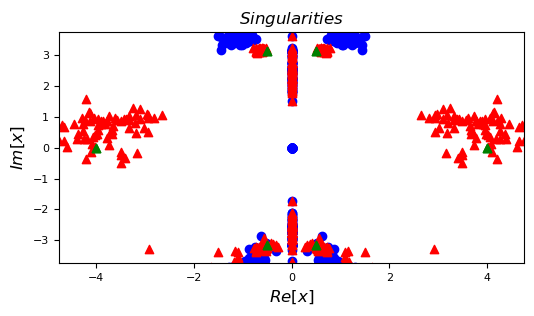

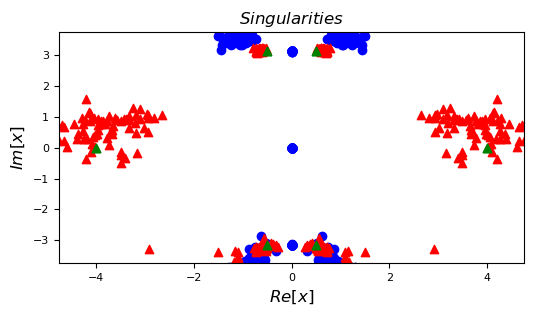

In [7]:
constraints = 3 * np.ones(len(xi_sim), dtype=int)

ncoeffs_num = 10
ncoeffs_den = 10
nsamples = 100
chi_threshold = 4.5
tol_cancellation = 5.0e-2

[sol_f_lst, roots_num_arr_lst, roots_den_arr_lst, chi_square_lst, residues_arr_lst] = padefit.mpfit(
    xi_sim, chis, dchis, constraints, ncoeffs_num, ncoeffs_den, nsamples=nsamples, ntasks=2)

print(f"\nPercentage of good fits: {np.sum(np.array(chi_square_lst) < chi_threshold) / np.array(chi_square_lst).size}\n")

#xx = np.linspace(np.min(xi_sim),np.max(xi_sim),100)
#plt.figure()
#for n in range(nsamples):
#    if chi_square_lst[n] < chi_threshold:
#        plt.plot(xx, sol_f_lst[n](xx), 'b-')
#plt.plot(xx, chi1(xx), 'g-')
#plt.ylim([-0.035,0.035])

plt.figure()
[a, b, c] = padefit.squeeze_roots_lst(roots_num_arr_lst, roots_den_arr_lst, chi_square_lst, residues_arr_lst, chi_threshold=chi_threshold, tol_cancellation=None)
plt.scatter(np.real(a),np.imag(a), marker='o', color='b')
plt.scatter(np.real(b),np.imag(b), marker='^', color='r')
plt.scatter(np.real(truesings),np.imag(truesings), marker='^', color='g')
plt.scatter(np.real(truesings),np.imag(truesings), marker='^', color='g')
plt.xlabel('$Re[x]$')
plt.ylabel('$Im[x]$')
plt.xlim([-4.75,4.75])
plt.ylim([-3.75,3.75])
plt.title("$Singularities$")

plt.figure()
[a, b, c] = padefit.squeeze_roots_lst(roots_num_arr_lst, roots_den_arr_lst, chi_square_lst, residues_arr_lst, chi_threshold=chi_threshold, tol_cancellation=tol_cancellation)
plt.scatter(np.real(a),np.imag(a), marker='o', color='b')
plt.scatter(np.real(b),np.imag(b), marker='^', color='r')
plt.scatter(np.real(truesings),np.imag(truesings), marker='^', color='g')
plt.scatter(np.real(truesings),np.imag(truesings), marker='^', color='g')
plt.xlabel('$Re[x]$')
plt.ylabel('$Im[x]$')
plt.xlim([-4.75,4.75])
plt.ylim([-3.75,3.75])
plt.title("$Singularities$")

plt.show()

Let's now increase the number of points, strategically chosen so as to better resolve the derivatives.

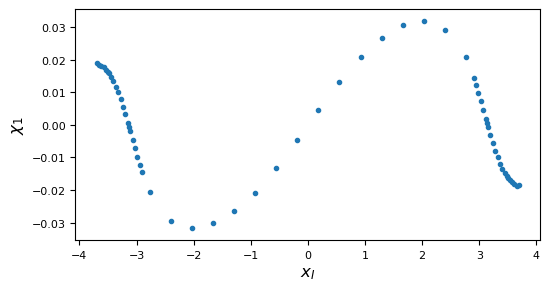

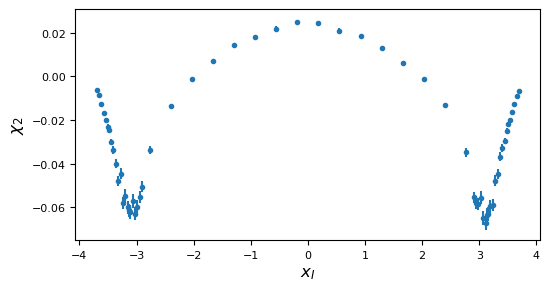

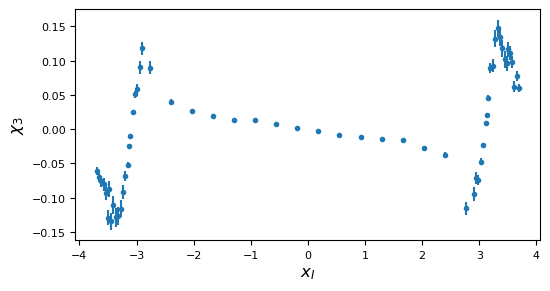

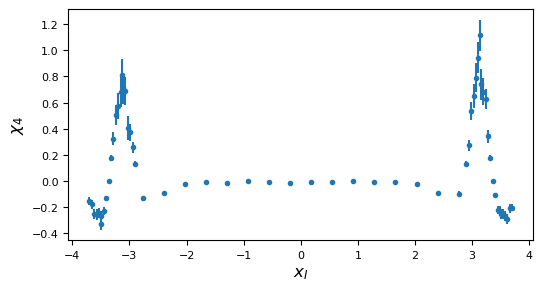

In [8]:
xi_sim = np.linspace(-3.50,3.50,20)

# add more points
xi_sim = np.append(xi_sim, np.linspace(-3.7,-2.9,20))
xi_sim = np.append(xi_sim, np.linspace(  2.9,3.7,20))
xi_sim = np.sort(xi_sim)

eps1 = 1.0e-2
eps2 = 5.0e-2
eps3 = 1.0e-1
eps4 = 1.5e-1

chis = [chi1(xi_sim),chi2(xi_sim), chi3(xi_sim), chi4(xi_sim)]
dchis = [eps1*np.abs(chis[0]), eps2*np.abs(chis[1]), eps3*np.abs(chis[2]), eps4*np.abs(chis[3])]

chis = [chis[0]+np.random.randn(len(xi_sim))*dchis[0],
        chis[1]+np.random.randn(len(xi_sim))*dchis[1],
        chis[2]+np.random.randn(len(xi_sim))*dchis[2],
        chis[3]+np.random.randn(len(xi_sim))*dchis[3]]

plt.figure()
plt.errorbar(xi_sim, chis[0], dchis[0], marker='.', linestyle='')
plt.xlabel("$x_I$")
plt.ylabel("$\chi_1$")

plt.figure()
plt.errorbar(xi_sim, chis[1], dchis[1], marker='.', linestyle='')
plt.xlabel("$x_I$")
plt.ylabel("$\chi_2$")

plt.figure()
plt.errorbar(xi_sim, chis[2], dchis[2], marker='.', linestyle='')
plt.xlabel("$x_I$")
plt.ylabel("$\chi_3$")

plt.figure()
plt.errorbar(xi_sim, chis[3], dchis[3], marker='.', linestyle='')
plt.xlabel("$x_I$")
plt.ylabel("$\chi_4$")

plt.show()

Now we fit to $R_{10}^{10}$ multi-point Pad\'e approximants, we choose $R_{10}^{10}$ because this is the lowest degree for which get good fits having $\frac{\chi_2}{ndof} \lesssim 4.5$ ($1.5$ times the number of derivatives included in the fit) in a significant number cases. We observe alternating clusters of poles and zeros signaling the presence of singularities close to the imaginary axis and other two clusters signaling the presence of the singularities on the real axis.

>>> Proc 601135 <<<
Number of points = 60
Number of constraints = 181 (for 60 points)
Number of coefficients = 22
Number of degrees of freedom = 159

Rational function: (C_0*x**10 + C_1*x**9 + C_10 + C_2*x**8 + C_3*x**7 + C_4*x**6 + C_5*x**5 + C_6*x**4 + C_7*x**3 + C_8*x**2 + C_9*x)/(C_11*x**10 + C_12*x**9 + C_13*x**8 + C_14*x**7 + C_15*x**6 + C_16*x**5 + C_17*x**4 + C_18*x**3 + C_19*x**2 + C_20*x + C_21)
--------------------------------------------------

>>> Proc 601134 <<<
Number of points = 60
Number of constraints = 181 (for 60 points)
Number of coefficients = 22
Number of degrees of freedom = 159

Rational function: (C_0*x**10 + C_1*x**9 + C_10 + C_2*x**8 + C_3*x**7 + C_4*x**6 + C_5*x**5 + C_6*x**4 + C_7*x**3 + C_8*x**2 + C_9*x)/(C_11*x**10 + C_12*x**9 + C_13*x**8 + C_14*x**7 + C_15*x**6 + C_16*x**5 + C_17*x**4 + C_18*x**3 + C_19*x**2 + C_20*x + C_21)
--------------------------------------------------

>>> Proc 601135 [sample #1 of 50] <<<
Rational function: (-6.50845113304053e-8


>>> Proc 601134 [sample #6 of 50] <<<
Rational function: (-3.24783887207393e-8*x**10 + 6.76306895742366e-7*x**9 + 1.63297428626593e-6*x**8 - 4.2012005724006e-5*x**7 - 2.70516131264728e-5*x**6 + 0.000862523916156778*x**5 + 0.000185572975280853*x**4 - 0.00756029048159229*x**3 - 0.000465080158685666*x**2 + 0.0245719369164656*x + 6.80636348609933e-5)/(7.39460959142635e-6*x**10 - 4.08116413247663e-6*x**9 - 0.000241089858540161*x**8 + 0.000117740867979747*x**7 + 0.002693386808137*x**6 - 0.00137372172416023*x**5 - 0.00145389038672082*x**4 + 0.00747439379404699*x**3 - 0.178339052330982*x**2 - 0.0154558152992058*x + 0.9741965780421)
--------------------------------------------------

>>> Proc 601135 [sample #7 of 50] <<<
Rational function: (-9.44557061709885e-8*x**10 + 8.15691125065196e-7*x**9 + 4.62370197082537e-6*x**8 - 4.6621888788557e-5*x**7 - 8.39077790753328e-5*x**6 + 0.000914328965177635*x**5 + 0.000677600018459054*x**4 - 0.0077419727056123*x**3 - 0.00207051952787259*x**2 + 0.0244281692


>>> Proc 601134 [sample #12 of 50] <<<
Rational function: (-4.80134286686807e-8*x**10 + 7.80000867853101e-7*x**9 + 2.36116097261542e-6*x**8 - 4.45791867999639e-5*x**7 - 4.43348874807984e-5*x**6 + 0.000875961528042113*x**5 + 0.000366871523147843*x**4 - 0.00747979413741743*x**3 - 0.00112335026300853*x**2 + 0.0239529462122273*x + 6.63786494101465e-5)/(5.50879374712704e-6*x**10 + 4.0236188564344e-7*x**9 - 0.000171275868384373*x**8 + 2.08125507305071e-5*x**7 + 0.00168977917260612*x**6 - 0.000889122232454547*x**5 + 0.00517530977155849*x**4 + 0.010774082901072*x**3 - 0.194073705493671*x**2 - 0.0423893441877185*x + 0.964424278824123)
--------------------------------------------------

>>> Proc 601135 [sample #13 of 50] <<<
Rational function: (-1.7009730905958e-7*x**10 + 8.11647447182549e-7*x**9 + 8.45814611749679e-6*x**8 - 4.50768723988552e-5*x**7 - 0.000158018510389348*x**6 + 0.000890014947058746*x**5 + 0.00134762448385039*x**4 - 0.00777988887305272*x**3 - 0.00442205835929232*x**2 + 0.025723


>>> Proc 601134 [sample #18 of 50] <<<
Rational function: (-4.54453784712496e-8*x**10 + 7.17273291974481e-7*x**9 + 2.51112253302535e-6*x**8 - 4.72033248894377e-5*x**7 - 4.99750249287986e-5*x**6 + 0.000963315891934226*x**5 + 0.000408175945549503*x**4 - 0.00824096758893391*x**3 - 0.00113956346935809*x**2 + 0.0260740390133255*x - 3.79649306639509e-5)/(1.00294966559786e-5*x**10 - 7.72469807249621e-7*x**9 - 0.00029670747748556*x**8 + 6.71097070338961e-5*x**7 + 0.0029407676602063*x**6 - 0.00144556430745053*x**5 + 0.00142960193504035*x**4 + 0.0132430593200854*x**3 - 0.207517961001093*x**2 - 0.0410051441693057*x + 1.04054744876889)
--------------------------------------------------

>>> Proc 601135 [sample #19 of 50] <<<
Rational function: (-7.32702681614184e-8*x**10 + 7.27275627474411e-7*x**9 + 3.62937827539529e-6*x**8 - 4.42374605019704e-5*x**7 - 6.59941589695087e-5*x**6 + 0.000897117133933819*x**5 + 0.00053164778421527*x**4 - 0.00783161300053273*x**3 - 0.00161851822631362*x**2 + 0.02553614


>>> Proc 601135 [sample #25 of 50] <<<
Rational function: (-8.5908682835223e-8*x**10 + 8.28241750814479e-7*x**9 + 4.04631301720671e-6*x**8 - 4.61716104076502e-5*x**7 - 7.73541188260535e-5*x**6 + 0.000910668445483964*x**5 + 0.000690390883080167*x**4 - 0.00785701779069883*x**3 - 0.00234615730717*x**2 + 0.0253682696910601*x - 7.50723279484528e-5)/(5.67782282572235e-6*x**10 + 5.92264608859401e-6*x**9 - 0.000201077967928043*x**8 - 0.000118447557229834*x**7 + 0.0023692450526132*x**6 - 0.000174712378812172*x**5 - 0.000324525541153759*x**4 + 0.0171431347003916*x**3 - 0.183458390589734*x**2 - 0.0996965555704025*x + 1.00036909107798)
--------------------------------------------------

>>> Proc 601134 [sample #24 of 50] <<<
Rational function: (4.46182470275027e-8*x**10 + 8.23321628663098e-7*x**9 - 2.26742331131634e-6*x**8 - 4.61210770783225e-5*x**7 + 4.32295746429238e-5*x**6 + 0.000900216220025161*x**5 - 0.000362129402460242*x**4 - 0.00776035124483984*x**3 + 0.00111169078519189*x**2 + 0.02543056


>>> Proc 601134 [sample #30 of 50] <<<
Rational function: (-8.03114133067078e-8*x**10 + 7.33319803707734e-7*x**9 + 3.78918826733579e-6*x**8 - 4.31877941375497e-5*x**7 - 7.01027854435073e-5*x**6 + 0.00086515470352847*x**5 + 0.00060954943656912*x**4 - 0.00754864757329382*x**3 - 0.00208437300591678*x**2 + 0.0247903615709187*x + 0.000159558681393879)/(5.56016097631114e-6*x**10 + 3.1281912460751e-6*x**9 - 0.000173834146503319*x**8 - 6.82629749931878e-5*x**7 + 0.0018069604174935*x**6 - 0.000204230785126893*x**5 + 0.0036745079294791*x**4 + 0.0125530856841415*x**3 - 0.190191328115439*x**2 - 0.0752920793864409*x + 0.996660865844645)
--------------------------------------------------

>>> Proc 601135 [sample #31 of 50] <<<
Rational function: (-4.82566655273517e-8*x**10 + 7.74535568037061e-7*x**9 + 2.1810978127116e-6*x**8 - 4.55377711042355e-5*x**7 - 4.1037698195167e-5*x**6 + 0.000901051925898011*x**5 + 0.000370052993043007*x**4 - 0.00776356719367306*x**3 - 0.00130569251205297*x**2 + 0.025282889


>>> Proc 601134 [sample #36 of 50] <<<
Rational function: (-1.27814470547326e-7*x**10 + 8.44249796338761e-7*x**9 + 6.09101360865228e-6*x**8 - 4.62417213532257e-5*x**7 - 0.000112375674743387*x**6 + 0.000895361616176434*x**5 + 0.000964557303509905*x**4 - 0.00764924807651043*x**3 - 0.00322080717085249*x**2 + 0.024724245090738*x + 4.31927201283217e-5)/(3.93217219561402e-6*x**10 + 3.54942977245455e-6*x**9 - 0.000122108138400618*x**8 - 6.32402943569654e-5*x**7 + 0.00113170816229053*x**6 - 0.000890324251213498*x**5 + 0.00800071253871364*x**4 + 0.0231770296474172*x**3 - 0.20242456030667*x**2 - 0.125761780751889*x + 0.996960483409273)
--------------------------------------------------

>>> Proc 601134 [sample #37 of 50] <<<
Rational function: (-4.25157487523225e-8*x**10 + 7.22500571917009e-7*x**9 + 1.96893767901535e-6*x**8 - 4.44636469323557e-5*x**7 - 3.72814550439099e-5*x**6 + 0.000890996451955273*x**5 + 0.000340546708554359*x**4 - 0.00760844409115877*x**3 - 0.00121651491702535*x**2 + 0.02419


>>> Proc 601135 [sample #42 of 50] <<<
Rational function: (-1.38842450661345e-7*x**10 + 7.51414727910171e-7*x**9 + 6.91777992108267e-6*x**8 - 4.42474352848738e-5*x**7 - 0.000132985497197225*x**6 + 0.000878082349138482*x**5 + 0.00115808643958796*x**4 - 0.00758577746710917*x**3 - 0.00379689278966274*x**2 + 0.0247443605416821*x - 0.000119833134829983)/(5.72511771463105e-6*x**10 + 2.72644136971291e-6*x**9 - 0.000167145701843476*x**8 + 3.02139308356117e-6*x**7 + 0.0015452138468515*x**6 - 0.00222358165092055*x**5 + 0.00653261951932125*x**4 + 0.0347277755723872*x**3 - 0.200568681633008*x**2 - 0.161891561626026*x + 1.00068817943137)
--------------------------------------------------

>>> Proc 601135 [sample #43 of 50] <<<
Rational function: (-1.89062590359717e-8*x**10 + 8.78376902125026e-7*x**9 + 7.80984318181359e-7*x**8 - 4.86124321323732e-5*x**7 - 1.20785173764205e-5*x**6 + 0.000938546794708731*x**5 + 7.59651733010741e-5*x**4 - 0.00794011806094169*x**3 - 0.000160035225447836*x**2 + 0.025343


>>> Proc 601135 [sample #48 of 50] <<<
Rational function: (-2.69985354609073e-8*x**10 + 8.53147599469281e-7*x**9 + 1.15553193851855e-6*x**8 - 4.63415861984166e-5*x**7 - 2.18188553924982e-5*x**6 + 0.00089967088704111*x**5 + 0.000203965920664858*x**4 - 0.00779024209597515*x**3 - 0.000757494179974007*x**2 + 0.025707590611583*x + 0.00014898151178239)/(3.26683272733746e-6*x**10 + 4.64454006347281e-6*x**9 - 0.000103648080293925*x**8 - 0.000138385180949278*x**7 + 0.000993211823698221*x**6 + 0.00139841904472106*x**5 + 0.00815787320931366*x**4 - 0.00426196888931713*x**3 - 0.204610520478836*x**2 - 0.00684195299393493*x + 1.04027544572466)
--------------------------------------------------

>>> Proc 601134 [sample #49 of 50] <<<
Rational function: (-7.16722004882067e-8*x**10 + 8.1672375002407e-7*x**9 + 3.5798729756142e-6*x**8 - 4.51000576671696e-5*x**7 - 6.4859947532181e-5*x**6 + 0.000880215596623202*x**5 + 0.000515653115019515*x**4 - 0.0075591665818252*x**3 - 0.00153676379922508*x**2 + 0.024474

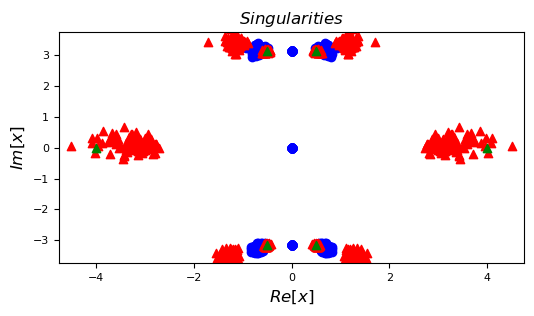

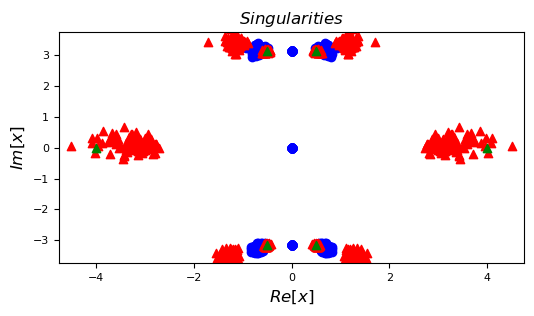

In [9]:
constraints = 3 * np.ones(len(xi_sim), dtype=int)

ncoeffs_num = 11
ncoeffs_den = 11
nsamples = 100
chi_threshold = 4.5
tol_cancellation = 5.0e-2

[sol_f_lst, roots_num_arr_lst, roots_den_arr_lst, chi_square_lst, residues_arr_lst] = padefit.mpfit(
    xi_sim, chis, dchis, constraints, ncoeffs_num, ncoeffs_den, nsamples=nsamples, ntasks=2)

print(f"\nPercentage of good fits: {np.sum(np.array(chi_square_lst) < chi_threshold) / np.array(chi_square_lst).size}\n")

#xx = np.linspace(np.min(xi_sim),np.max(xi_sim),100)
#plt.figure()
#for n in range(nsamples):
#    if chi_square_lst[n] < chi_threshold:
#        plt.plot(xx, sol_f_lst[n](xx), 'b-')
#plt.plot(xx, chi1(xx), 'g-')
#plt.ylim([-0.035,0.035])

plt.figure()
[a, b, c] = padefit.squeeze_roots_lst(roots_num_arr_lst, roots_den_arr_lst, chi_square_lst, residues_arr_lst, chi_threshold=chi_threshold, tol_cancellation=None)
plt.scatter(np.real(a),np.imag(a), marker='o', color='b')
plt.scatter(np.real(b),np.imag(b), marker='^', color='r')
plt.scatter(np.real(truesings),np.imag(truesings), marker='^', color='g')
plt.xlabel('$Re[x]$')
plt.ylabel('$Im[x]$')
plt.xlim([-4.75,4.75])
plt.ylim([-3.75,3.75])
plt.title("$Singularities$")

plt.figure()
[a, b, c] = padefit.squeeze_roots_lst(roots_num_arr_lst, roots_den_arr_lst, chi_square_lst, residues_arr_lst, chi_threshold=chi_threshold, tol_cancellation=tol_cancellation)
plt.scatter(np.real(a),np.imag(a), marker='o', color='b')
plt.scatter(np.real(b),np.imag(b), marker='^', color='r')
plt.scatter(np.real(truesings),np.imag(truesings), marker='^', color='g')
plt.xlabel('$Re[x]$')
plt.ylabel('$Im[x]$')
plt.xlim([-4.75,4.75])
plt.ylim([-3.75,3.75])
plt.title("$Singularities$")

plt.show()

Finally we save the zeros and poles for later use.

In [10]:
np.savetxt("data/padefit-example-zeros-re.dat", np.real(a))
np.savetxt("data/padefit-example-zeros-im.dat", np.imag(a))

np.savetxt("data/padefit-example-poles-re.dat", np.real(b))
np.savetxt("data/padefit-example-poles-im.dat", np.imag(b))